# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test6b prob compare

Notebook equivalent of `tests/4_earth/test6b_prob_compare.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test6b_prob_compare"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test6b_prob_compare.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test6b_prob_compare


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_case_a_flavourbasis_analytical_vs_numerical`

**What is checked:** Case a flavourbasis analytical vs numerical behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_case_a_flavourbasis_analytical_vs_numerical)


Running test_case_a_flavourbasis_analytical_vs_numerical ...

Case A through-earth flavour-basis comparison:
E [MeV]       : 1000.0
eta [rad]     : 0.6
depth [m]     : 0.0
P analytical  : tensor([9.3574076642e-01, 5.1840902093e-02, 1.2418331484e-02], dtype=torch.float64)
P numerical   : tensor([9.3653384509e-01, 5.1197584872e-02, 1.2268570033e-02], dtype=torch.float64)
max |diff|    : 7.930787e-04
tolerance     : 5.000000e-03
Checking: Case A through-earth flavour-basis comparison analytical probabilities
  P shape  : (3,)
  min/max P: 0.01241833148434046 0.9357407664229165
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
Checking: Case A through-earth flavour-basis comparison numerical probabilities
  P shape  : (3,)
  min/max P: 0.012268570032939284 0.936533845094985
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_case_a_flavourbasis_analytical_vs_numerical


## Test: `test_case_b_flavourbasis_analytical_vs_numerical`

**What is checked:** Case b flavourbasis analytical vs numerical behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_case_b_flavourbasis_analytical_vs_numerical)


Running test_case_b_flavourbasis_analytical_vs_numerical ...

Case B underground flavour-basis comparison:
E [MeV]       : 1000.0
eta [rad]     : 2.4
depth [m]     : 1000.0
P analytical  : tensor([9.9999838307e-01, 8.5393429552e-07, 7.6299412227e-07], dtype=torch.float64)
P numerical   : tensor([9.9999838307e-01, 8.5393429552e-07, 7.6299412227e-07], dtype=torch.float64)
max |diff|    : 8.215650e-15
tolerance     : 5.000000e-06
Checking: Case B underground flavour-basis comparison analytical probabilities
  P shape  : (3,)
  min/max P: 7.629941222720946e-07 0.9999983830715818
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
Checking: Case B underground flavour-basis comparison numerical probabilities
  P shape  : (3,)
  min/max P: 7.62994122272512e-07 0.9999983830715736
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_case_b_flavourbasis_analytical_vs_numerical


## Test: `test_numerical_full_oscillation_final_matches_final_only`

**What is checked:** Numerical full oscillation final matches final only behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Full numerical evolution must have shape (nsteps + 1, 3); Numerical x grid must have nsteps + 1 points; Final full-path state must match final-only numerical result.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_numerical_full_oscillation_final_matches_final_only)


Running test_numerical_full_oscillation_final_matches_final_only ...

Numerical full-path consistency:
evolution shape: (81, 3)
x shape        : (81,)
final path     : tensor([9.3653384509e-01, 5.1197584872e-02, 1.2268570033e-02], dtype=torch.float64)
final only     : tensor([9.3653384509e-01, 5.1197584872e-02, 1.2268570033e-02], dtype=torch.float64)
max |diff|     : 0.000000e+00
Checking: Final full-path numerical probabilities
  P shape  : (3,)
  min/max P: 0.012268570032939284 0.936533845094985
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_numerical_full_oscillation_final_matches_final_only


## Test: `test_massbasis_diagnostic_difference_is_finite`

**What is checked:** Massbasis diagnostic difference is finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Mass-basis analytical/numerical difference must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_massbasis_diagnostic_difference_is_finite)


Running test_massbasis_diagnostic_difference_is_finite ...

Mass-basis diagnostic comparison:
P analytical: tensor([4.4706579129e-01, 2.9091556912e-01, 2.6201863959e-01], dtype=torch.float64)
P numerical : tensor([5.8539139018e-01, 6.8797608070e-03, 4.0772884901e-01], dtype=torch.float64)
max |diff|  : 2.840358e-01
Note        : mass-basis comparison is diagnostic; flavour-basis is the tight consistency check.
Checking: Mass-basis analytical probabilities
  P shape  : (3,)
  min/max P: 0.2620186395923912 0.44706579128743235
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
Checking: Mass-basis numerical probabilities
  P shape  : (3,)
  min/max P: 0.006879760806983452 0.585391390184974
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_massbasis_diagnostic_difference_is_finite


## Plot: `plot_case_a_probability_bars()`

**What is checked:** Case a probability bars behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_prob_compare_case_a_bars.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_case_a_probability_bars()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_prob_compare_case_a_bars.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_case_a_probability_bars() ...

Case A plot data:
E [MeV]       : 1000.0
eta [rad]     : 0.6
depth [m]     : 0.0
P analytical  : tensor([9.3574076642e-01, 5.1840902093e-02, 1.2418331484e-02], dtype=torch.float64)
P numerical   : tensor([9.3653384509e-01, 5.1197584872e-02, 1.2268570033e-02], dtype=torch.float64)
max |diff|    : 7.930787e-04
tolerance     : 5.000000e-03
Checking: Case A plot data analytical probabilities
  P shape  : (3,)
  min/max P: 0.01241833148434046 0.9357407664229165
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
Checking: Case A plot data numerical probabilities
  P shape  : (3,)
  min/max P: 0.012268570032939284 0.936533845094985
  sum(P)   : tensor(1.0000000000e+00, dtype=torch.float64)
Saved plot: V:\output\test\earth\test6b_prob_compare\plot_case_a_probability_bars_figure_001.png


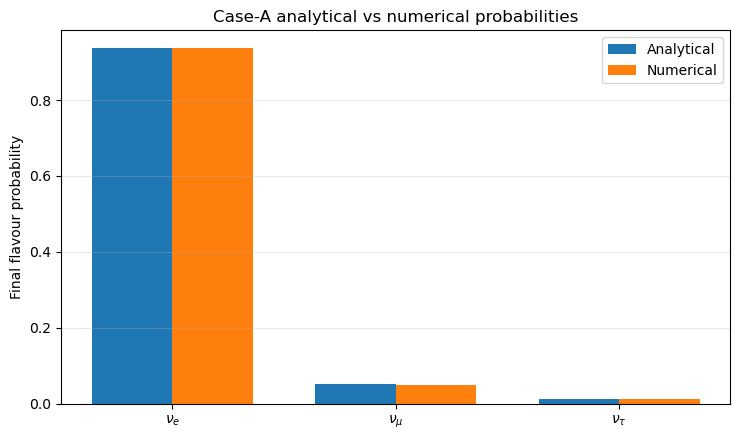

PASSED: plot_case_a_probability_bars()


In [8]:
run_notebook_call('plot_case_a_probability_bars()', lambda: TEST_MODULE.plot_case_a_probability_bars())


## Plot: `plot_error_vs_eta()`

**What is checked:** Error vs eta behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_prob_compare_error_vs_eta.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_error_vs_eta()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_prob_compare_error_vs_eta.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_error_vs_eta() ...
Saved plot: V:\output\test\earth\test6b_prob_compare\plot_error_vs_eta_figure_001.png


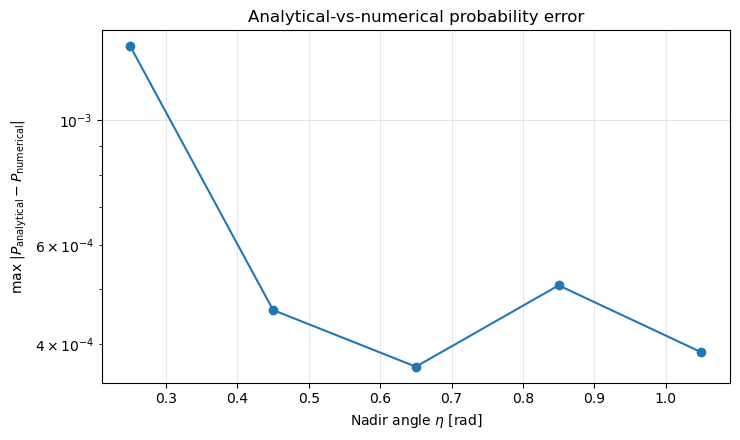

PASSED: plot_error_vs_eta()


In [9]:
run_notebook_call('plot_error_vs_eta()', lambda: TEST_MODULE.plot_error_vs_eta())


## Plot: `plot_numerical_path_evolution()`

**What is checked:** Numerical path evolution behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_prob_compare_numerical_path.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_numerical_path_evolution()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_prob_compare_numerical_path.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_numerical_path_evolution() ...
Saved plot: V:\output\test\earth\test6b_prob_compare\plot_numerical_path_evolution_figure_001.png


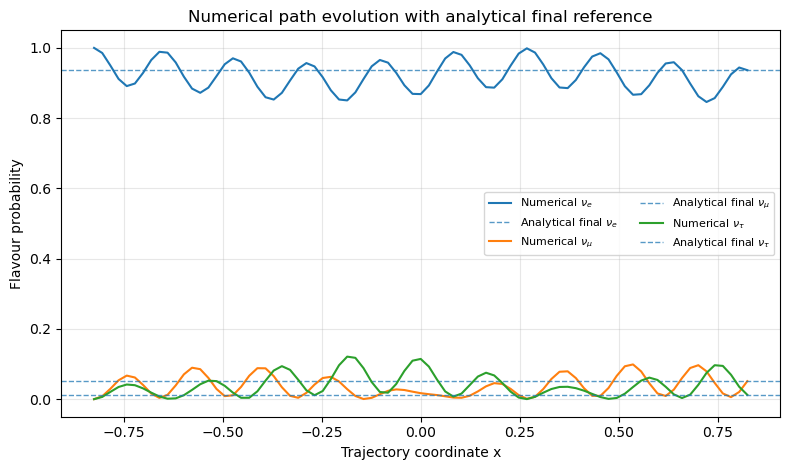

PASSED: plot_numerical_path_evolution()


In [10]:
run_notebook_call('plot_numerical_path_evolution()', lambda: TEST_MODULE.plot_numerical_path_evolution())
